In [2]:
import sys
!{sys.executable} -m pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 5.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 5.0 MB/s eta 0:00:00a 0:00:01


In [1]:
# --- TOP CELL: RUN THIS ONCE ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported too
from scipy.integrate import solve_ivp
import os
from sklearn.metrics import mean_squared_error, r2_score
# --- 2. SUPERCHARGED OPTIMIZER ---
from scipy.optimize import minimize, differential_evolution
import multiprocessing
# -------------------------------

In [2]:
import pandas as pd
import numpy as np
import os

print("Cell 1: Memuat dataset hasil pemrosesan...")

MW = {
    'desb30': 5706.524, 'detemir': 5916.885, 'A1': 5916.885, 
    'A1_B1': 6127.246, 'A1_B29': 6127.246, 'B1_B29': 6127.246, 
    'A1_B29_B1': 6337.607, 'B1': 5916.885, 'nhs_myr': 325.449, 'nhs': 115.088
}

# Pastikan daftar ini sesuai dengan nilai unik di kolom 'Peak Identification' file kita
species_list = ['desb30', 'A1', 'detemir', 'A1_B29', 'B1_B29', 'A1_B29_B1', 'A1_B1', 'B1']

csv_filename = 'kinetic_data_processed.csv'
if not os.path.exists(csv_filename):
    raise FileNotFoundError(f"File '{csv_filename}' tidak ditemukan!")

df = pd.read_csv(csv_filename)

# Pastikan tipe data benar
df['Time'] = df['Time'].astype(float)
df['Perbandingan'] = df['Perbandingan'].astype(float)

experimental_dataset = {}
ratios = sorted(df['Perbandingan'].unique())
# Dapatkan daftar waktu unik yang tersedia dalam data (diurutkan)
time_points = sorted(df['Time'].unique())

for r in ratios:
    df_ratio = df[df['Perbandingan'] == r]
    experimental_dataset[r] = {}
    
    for sp in species_list:
        # Ambil data untuk spesies ini, urutkan berdasarkan Time
        sub_df = df_ratio[df_ratio['Peak Identification'] == sp].sort_values('Time')
        
        # Ekstrak konsentrasi (g/L) dan bagi dengan MW untuk mendapatkan Molaritas
        # Kita gunakan reindex untuk memastikan semua time_points ada (mengisi NaN dengan 0.0)
        conc_series = sub_df.set_index('Time').reindex(time_points, fill_value=0.0)['Conc']
        
        experimental_dataset[r][sp] = np.array(conc_series) / MW.get(sp, 1.0)

print("Cell 1 Selesai: Dataset telah dikonversi ke Molaritas.")
# Opsional: Cek hasil untuk satu perbandingan
print(f"Time points: {time_points}")
print(f"Contoh data (Ratio 1.0, desb30): {experimental_dataset[1.0]['desb30'][:5]}")

Cell 1: Memuat dataset hasil pemrosesan...
Cell 1 Selesai: Dataset telah dikonversi ke Molaritas.
Time points: [0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 13.0, 16.0, 19.0, 22.0, 25.0, 30.0, 35.0, 40.0, 45.0, 50.0, 60.0, 70.0, 80.0, 100.0, 120.0]
Contoh data (Ratio 1.0, desb30): [2.53253995e-04 7.90481211e-05 4.58773152e-05 3.68893568e-05
 3.47426910e-05]


In [3]:
import numpy as np
from scipy.integrate import solve_ivp

class FinalKineticModel:
    def __init__(self, params):
        # CHANGED: Now expects 8 k-values (index 0 to 7)
        self.k = params[:8] 
        # CHANGED: Indices for n and m shifted by 1
        self.n = params[8]
        self.m = params[9]
        
        self.species = ['nhs_myr', 'desb30', 'A1', 'detemir', 'B1', 'A1_B29', 'B1_B29', 'A1_B1', 'A1_B29_B1']
        self.idx = {name: i for i, name in enumerate(self.species)}

    def _ode_system(self, t, y):
        # 1. HARD CLIP: Force all concentrations to be at least 1e-12
        # This prevents the solver from ever trying to calculate negative numbers
        y_safe = np.maximum(y, 1e-12)
        idx = self.idx
        
        C_nhsm = y_safe[idx['nhs_myr']]
        C_desb = y_safe[idx['desb30']]
        C_a1   = y_safe[idx['A1']]
        C_det  = y_safe[idx['detemir']]
        C_a1b29= y_safe[idx['A1_B29']]
        
        r1 = self.k[0] * (C_nhsm**self.n) * (C_desb**self.m)
        r2 = self.k[1] * (C_nhsm**self.n) * (C_desb**self.m)
        r3 = self.k[2] * (C_nhsm**self.n) * (C_desb**self.m)
        
        r4 = self.k[3] * (C_nhsm**self.n) * (C_a1**self.m)
        r5 = self.k[4] * (C_nhsm**self.n) * (C_a1**self.m)
        
        r6 = self.k[5] * (C_nhsm**self.n) * (C_det**self.m)
        r7 = self.k[6] * (C_nhsm**self.n) * (C_a1b29**self.m)
        
        # NEW: Hydrolysis Rate 
        r_hydro = self.k[7] * C_nhsm 
        
        dydt = np.zeros_like(y)
        
        # CHANGED: nhs_myr is consumed by hydrolysis too
        dydt[idx['nhs_myr']]  = -(r1 + r2 + r3 + r4 + r5 + r6 + r7) - r_hydro
        dydt[idx['desb30']]   = -(r1 + r2 + r3)
        dydt[idx['A1']]       = r1 - (r4 + r5)
        dydt[idx['B1']]       = r2
        dydt[idx['detemir']]  = r3 - r6
        dydt[idx['A1_B1']]    = r4
        dydt[idx['A1_B29']]   = r5 - r7
        dydt[idx['B1_B29']]   = r6
        dydt[idx['A1_B29_B1']]= r7
        
        return dydt

    def simulate(self, y0, t_span, t_eval):
        # CHANGED: method='Radau' and tighter tolerances for the fast reaction
        return solve_ivp(self._ode_system, t_span, y0, t_eval=np.sort(t_eval), 
                         method='Radau', atol=1e-9, rtol=1e-7)

# Ensure time_exp is defined in the current cell
time_exp = np.sort(df['Time'].unique())

In [4]:
def get_initial_conditions(ratio, experimental_dataset):
    # 1. Get desb30 molarity at t=0
    desb30_t0 = experimental_dataset[ratio]['desb30'][0]
    
    # 2. Calculate nhs_myr as requested
    nhs_myr_t0 = desb30_t0 * ratio
    
    # 3. Build the y0 array based on the class order
    # Note: Products are 0.0 at t=0
    y0 = np.zeros(9)
    y0[idx['nhs_myr']] = nhs_myr_t0
    y0[idx['desb30']]  = desb30_t0
    # Everything else (A1, detemir, etc.) stays 0.0
    
    return y0

In [5]:
# --- 1. BALANCED ABSOLUTE WEIGHTS ---
weights = {
    'desb30': 2.0,
    'A1': 1.0,
    'detemir': 3.0,   # Strong priority, but not overwhelming
    'B1': 0.5, 'A1_B1': 0.5, 'A1_B29': 0.5, 'B1_B29': 0.5, 'A1_B29_B1': 0.5
}

# --- 2. THE OBJECTIVE FUNCTION (n, m now FREE parameters) ---
# CHANGED: n and m are no longer hardcoded to 1.0. That line was the reason the
# optimizer could never report anything but 1.000 for the reaction orders - it
# never had the freedom to search anywhere else.
#
# CHANGED: the hard mass-balance "return 1e12" cliff is replaced with a smooth
# quadratic penalty. A hard cliff has no gradient, which breaks the L-BFGS-B
# polishing stage (Stage 2) even though Differential Evolution can tolerate it.
MASS_BALANCE_PENALTY_WEIGHT = 1e6  # tune this: larger = stricter mass balance

def objective_function_full(params):
    k_vals = np.exp(params[:8])
    n, m = params[8], params[9]          # <-- now fitted, not fixed

    # Reject ridiculously high k-values immediately (kept from original)
    if np.any(k_vals > 1e8):
        return 1e12

    full_params = list(k_vals) + [n, m]
    total_sse_weighted = 0.0
    model = FinalKineticModel(full_params)

    for r in ratios:
        desb30_t0_molL = experimental_dataset[r]['desb30'][0]
        y0 = np.zeros(len(model.species))
        y0[model.idx['nhs_myr']] = desb30_t0_molL * r
        y0[model.idx['desb30']] = desb30_t0_molL

        sol = model.simulate(y0, (0, 120), time_exp)

        # ODE Crash check - still a hard reject, this is a genuine numerical failure
        if not sol.success or np.any(np.isnan(sol.y)) or np.any(np.isinf(sol.y)):
            return 1e12

        # THE BACKBONE MASS BALANCE CHECK -> now a SOFT penalty instead of a cliff
        moles_in = desb30_t0_molL
        moles_out = np.sum([sol.y[model.idx[sp]][-1] for sp in model.species if sp != 'nhs_myr'])
        rel_drift = abs(moles_in - moles_out) / moles_in
        total_sse_weighted += MASS_BALANCE_PENALTY_WEIGHT * rel_drift**2

        # ERROR CALCULATION
        for sp in model.species:
            if sp == 'nhs_myr':
                continue
            sim_vals = sol.y[model.idx[sp]] * MW[sp]
            exp_vals = experimental_dataset[r][sp] * MW[sp]

            mask = ~np.isnan(exp_vals) & (exp_vals > 1e-6)
            if np.any(mask):
                abs_error = (sim_vals[mask] - exp_vals[mask])
                total_sse_weighted += np.sum((abs_error * weights[sp])**2)

    return total_sse_weighted


# ==============================================================================
# STAGE 0 (diagnostic / warm start): fit with n = m = 1 fixed, exactly like the
# original notebook did. We keep this so you have a clean baseline SSE to compare
# against once n, m are freed in Stage A below - if freeing them doesn't improve
# SSE by much, that's evidence first-order really is the right mechanism.
# ==============================================================================
def objective_function_first_order(log_k):
    return objective_function_full(np.concatenate([log_k, [1.0, 1.0]]))

bounds_k_only = [(np.log(1e-6), np.log(1e7))] * 8  # widened: k3 pinned to 1e5 in testing

print("Stage 0: Baseline first-order fit (n = m = 1, for comparison)...")
res_de0 = differential_evolution(
    objective_function_first_order, bounds_k_only,
    popsize=30, maxiter=100, mutation=(0.5, 1.5), recombination=0.7,
    workers=4, updating='deferred', seed=42   # 4 real cores, no cgroup limit found
)
res_first_order = minimize(
    objective_function_first_order, res_de0.x, method='L-BFGS-B',
    bounds=bounds_k_only, options={'ftol': 1e-9, 'maxiter': 1000}
)
print(f"Baseline (n=m=1) SSE: {res_first_order.fun:.4f}")

# ==============================================================================
# STAGE A: Global optimization with k, n, m ALL free (10-dimensional)
# We warm-start the k's from Stage 0's result so DE isn't searching blind, and
# give n, m a physically reasonable range (0.1 - 4) rather than letting them
# roam into nonsensical orders.
# ==============================================================================
n_m_bounds = [(0.1, 4.0), (0.1, 4.0)]
bounds_full = bounds_k_only + n_m_bounds

print("\nStage A: Global optimization (Differential Evolution) with n, m free...")
print("Searching 10-dimensional parameter space...")

# Build an initial population that includes the Stage 0 solution (k's warm-started,
# n = m = 1 as one guess) plus random perturbations, so DE isn't starting blind.
# differential_evolution doesn't take a single-point x0, but it does accept a
# full initial population array via `init`.
rng = np.random.default_rng(42)
n_dims = len(bounds_full)
pop_size = 40 * n_dims  # matches popsize=40 below
init_center = np.concatenate([res_first_order.x, [1.0, 1.0]])
init_pop = np.tile(init_center, (pop_size, 1))
# perturb everything except the first row, and clip to bounds
lo = np.array([b[0] for b in bounds_full])
hi = np.array([b[1] for b in bounds_full])
noise = rng.normal(scale=0.5, size=init_pop.shape)
noise[:, -2:] *= 0.6  # smaller perturbation for n, m specifically
init_pop[1:] += noise[1:]
init_pop = np.clip(init_pop, lo, hi)

res_de = differential_evolution(
    objective_function_full,
    bounds_full,
    popsize=40,
    maxiter=200,
    mutation=(0.5, 1.5),
    recombination=0.7,
    workers=4,
    updating='deferred',
    seed=42,
    init=init_pop
)

print("Stage B: Local refinement (L-BFGS-B Polishing)...")
res_final = minimize(
    objective_function_full,
    res_de.x,
    method='L-BFGS-B',
    bounds=bounds_full,
    options={'ftol': 1e-9, 'maxiter': 1000}
)

final_params = list(res_final.x[:8]) + list(res_final.x[8:10])  # k's stay in log-space here, n/m already linear
print(f"Refined SSE (n, m free): {res_final.fun:.4f}")
print(f"Fitted n = {res_final.x[8]:.4f}, m = {res_final.x[9]:.4f}")


# ---- BOUNDARY CHECK: flag any fitted parameter sitting on (or near) its bound ----
# A parameter pinned to its bound is a red flag: either the bound is too tight,
# or that parameter is practically unidentifiable from this data (the model is
# insensitive to it once it's "big enough" / "small enough"). Don't trust such
# a parameter's fitted value at face value.
print("\n--- Boundary check ---")
for name, val, (lo, hi) in zip(
    ['k1','k2','k3','k4','k5','k6','k7','k_hydro','n','m'],
    list(res_final.x[:8]) + [res_final.x[8], res_final.x[9]],
    bounds_full
):
    span = hi - lo
    if span > 0 and (val - lo) / span < 0.02:
        print(f"  WARNING: {name} is within 2% of its LOWER bound ({lo:.3f}) - value may be unreliable")
    elif span > 0 and (hi - val) / span < 0.02:
        print(f"  WARNING: {name} is within 2% of its UPPER bound ({hi:.3f}) - value may be unreliable")


Stage 0: Baseline first-order fit (n = m = 1, for comparison)...


/home/jupyter-rnd57/.local/lib/python3.10/site-packages/scipy/integrate/_ivp/common.py:356: RuntimeWarning: overflow encountered in multiply
  new_factor = NUM_JAC_FACTOR_INCREASE * factor[ind]
/home/jupyter-rnd57/.local/lib/python3.10/site-packages/scipy/integrate/_ivp/common.py:378: RuntimeWarning: overflow encountered in multiply
  factor[max_diff < NUM_JAC_DIFF_SMALL * scale] *= NUM_JAC_FACTOR_INCREASE
/home/jupyter-rnd57/.local/lib/python3.10/site-packages/scipy/integrate/_ivp/common.py:356: RuntimeWarning: overflow encountered in multiply
  new_factor = NUM_JAC_FACTOR_INCREASE * factor[ind]
/home/jupyter-rnd57/.local/lib/python3.10/site-packages/scipy/integrate/_ivp/common.py:378: RuntimeWarning: overflow encountered in multiply
  factor[max_diff < NUM_JAC_DIFF_SMALL * scale] *= NUM_JAC_FACTOR_INCREASE
/home/jupyter-rnd57/.local/lib/python3.10/site-packages/scipy/integrate/_ivp/common.py:356: RuntimeWarning: overflow encountered in multiply
  new_factor = NUM_JAC_FACTOR_INCREASE 

Baseline (n=m=1) SSE: 3.9837

Stage A: Global optimization (Differential Evolution) with n, m free...
Searching 10-dimensional parameter space...


/home/jupyter-rnd57/.local/lib/python3.10/site-packages/scipy/integrate/_ivp/common.py:356: RuntimeWarning: overflow encountered in multiply
  new_factor = NUM_JAC_FACTOR_INCREASE * factor[ind]
/home/jupyter-rnd57/.local/lib/python3.10/site-packages/scipy/integrate/_ivp/common.py:378: RuntimeWarning: overflow encountered in multiply
  factor[max_diff < NUM_JAC_DIFF_SMALL * scale] *= NUM_JAC_FACTOR_INCREASE


Stage B: Local refinement (L-BFGS-B Polishing)...
Refined SSE (n, m free): 3.2525
Fitted n = 1.2377, m = 1.5964

--- Boundary check ---


In [6]:
opt_k = np.exp(final_params[:8])
opt_orders = final_params[8:]        # <-- these are now the ACTUAL fitted values
fp = list(opt_k) + list(opt_orders)

print("\n================== HASIL KINETIKA MEKANISTIK GLOBAL ==================")
pathway_names = [
    'k1 (DesB30 -> A1)      ', 'k2 (DesB30 -> B1)      ', 'k3 (DesB30 -> Detemir) ',
    'k4 (A1 -> A1_B1)       ', 'k5 (A1 -> A1_B29)      ', 'k6 (Detemir -> B1_B29) ',
    'k7 (A1_B29 -> Tri)     ', 'k_hydro (NHS_myr hydrolisis)'
]
for name, val in zip(pathway_names, opt_k):
    print(f"  {name}: {val:.4e}")
print(f"  Order 'n' (NHS-myr)         : {opt_orders[0]:.3f}")
print(f"  Order 'm' (Substrat Insulin): {opt_orders[1]:.3f}")
print(f"  Final Minimum SSE (g/L)     : {res_final.fun:.5f}")
print(f"  (Baseline SSE at n=m=1 was  : {res_first_order.fun:.5f} - compare to see if freeing n,m actually helped)")
print("======================================================================\n")

# 1. Define the model with the final optimized parameters
model = FinalKineticModel(fp)

print("=== ANALISIS MASS CONVERSION & YIELD (MENIT KE-120) ===")
for r in ratios:
    desb30_t0_molL = experimental_dataset[r]['desb30'][0]

    y0 = np.zeros(len(model.species))
    y0[model.idx['nhs_myr']] = desb30_t0_molL * r
    y0[model.idx['desb30']] = desb30_t0_molL

    sol = model.simulate(y0, (0, 120), time_exp)

    desb30_0_mass = desb30_t0_molL * MW['desb30']
    desb30_akhir_mass = sol.y[model.idx['desb30']][-1] * MW['desb30']
    detemir_akhir_mass = sol.y[model.idx['detemir']][-1] * MW['detemir']

    konversi = ((desb30_0_mass - desb30_akhir_mass) / desb30_0_mass) * 100
    yield_detemir = (detemir_akhir_mass / desb30_0_mass) * 100

    print(f"Rasio Skenario : {r}")
    print(f"  -> Konversi Massa DesB30 : {konversi:.2f}%")
    print(f"  -> Yield Hasil Detemir    : {yield_detemir:.2f}%")



================== HASIL KINETIKA MEKANISTIK GLOBAL ==================
  k1 (DesB30 -> A1)      : 4.0193e+05
  k2 (DesB30 -> B1)      : 3.1408e+06
  k3 (DesB30 -> Detemir) : 1.0000e+07
  k4 (A1 -> A1_B1)       : 1.1411e+04
  k5 (A1 -> A1_B29)      : 5.6443e-05
  k6 (Detemir -> B1_B29) : 4.4071e-04
  k7 (A1_B29 -> Tri)     : 3.1932e+03
  k_hydro (NHS_myr hydrolisis): 7.8636e-02
  Order 'n' (NHS-myr)         : 1.238
  Order 'm' (Substrat Insulin): 1.596
  Final Minimum SSE (g/L)     : 3.25246
  (Baseline SSE at n=m=1 was  : 3.98368 - compare to see if freeing n,m actually helped)

=== ANALISIS MASS CONVERSION & YIELD (MENIT KE-120) ===
Rasio Skenario : 1.0
  -> Konversi Massa DesB30 : 86.38%
  -> Yield Hasil Detemir    : 66.13%
Rasio Skenario : 1.5
  -> Konversi Massa DesB30 : 87.10%
  -> Yield Hasil Detemir    : 66.69%
Rasio Skenario : 2.0
  -> Konversi Massa DesB30 : 91.40%
  -> Yield Hasil Detemir    : 69.98%


In [7]:
# 1. Transform the first 8 parameters from log-space to linear physical space
linear_k_vals = np.exp(res_final.x[:8])

# 2. Use the FITTED reaction orders, not hardcoded constants
linear_params = list(linear_k_vals) + [res_final.x[8], res_final.x[9]]

# 3. INSTANTIATE THE MODEL WITH THE CORRECT LINEAR PARAMETERS
model = FinalKineticModel(linear_params)

# --- Print Summary ---
print("\n================== HASIL KINETIKA MEKANISTIK GLOBAL ==================")
pathway_names = [
    'k1 (DesB30 -> A1)', 'k2 (DesB30 -> B1)', 'k3 (DesB30 -> Detemir)',
    'k4 (A1 -> A1_B1)', 'k5 (A1 -> A1_B29)', 'k6 (Detemir -> B1_B29)',
    'k7 (A1_B29 -> Tri)', 'k_hydro (NHS_myr hydrolisis)'
]

for name, val in zip(pathway_names, linear_k_vals):
    print(f"  {name:28}: {val:.4e}")
print(f"  Order 'n' (NHS-myr)         : {res_final.x[8]:.3f}")
print(f"  Order 'm' (Substrat Insulin): {res_final.x[9]:.3f}")
print(f"  Final Minimum SSE (g/L)     : {res_final.fun:.5f}")
print("======================================================================\n")

print("=== ANALISIS MASS CONVERSION & YIELD (MENIT KE-120) ===")

for r in ratios:
    desb30_t0_molL = experimental_dataset[r]['desb30'][0]
    y0 = np.zeros(len(model.species))
    y0[model.idx['nhs_myr']] = desb30_t0_molL * r
    y0[model.idx['desb30']] = desb30_t0_molL

    sol_exp = model.simulate(y0, (0, 120), time_exp)

    if not sol_exp.success or np.any(np.isnan(sol_exp.y)):
        print(f"Simulation failed for Ratio {r}")
        continue

    konversi_desb = (desb30_t0_molL - sol_exp.y[model.idx['desb30']][-1]) / desb30_t0_molL * 100
    yield_detemir = (sol_exp.y[model.idx['detemir']][-1]) / desb30_t0_molL * 100
    print(f"Rasio Skenario : {r}")
    print(f"  -> Konversi Massa DesB30 : {konversi_desb:.2f}%")
    print(f"  -> Yield Hasil Detemir    : {yield_detemir:.2f}%")



================== HASIL KINETIKA MEKANISTIK GLOBAL ==================
  k1 (DesB30 -> A1)           : 4.0193e+05
  k2 (DesB30 -> B1)           : 3.1408e+06
  k3 (DesB30 -> Detemir)      : 1.0000e+07
  k4 (A1 -> A1_B1)            : 1.1411e+04
  k5 (A1 -> A1_B29)           : 5.6443e-05
  k6 (Detemir -> B1_B29)      : 4.4071e-04
  k7 (A1_B29 -> Tri)          : 3.1932e+03
  k_hydro (NHS_myr hydrolisis): 7.8636e-02
  Order 'n' (NHS-myr)         : 1.238
  Order 'm' (Substrat Insulin): 1.596
  Final Minimum SSE (g/L)     : 3.25246

=== ANALISIS MASS CONVERSION & YIELD (MENIT KE-120) ===
Rasio Skenario : 1.0
  -> Konversi Massa DesB30 : 86.38%
  -> Yield Hasil Detemir    : 63.78%
Rasio Skenario : 1.5
  -> Konversi Massa DesB30 : 87.10%
  -> Yield Hasil Detemir    : 64.32%
Rasio Skenario : 2.0
  -> Konversi Massa DesB30 : 91.40%
  -> Yield Hasil Detemir    : 67.49%


In [8]:
import dill

# 1. Ensure your model is using the linear, optimized parameters
# (Important: Use np.exp for k-values, not the raw log-space res_final.x)
final_linear_params = list(np.exp(res_final.x[:8])) + [opt_orders[0], opt_orders[1]]
final_model = FinalKineticModel(final_linear_params)

# 2. Create a "Bundle" dictionary
# This saves the model, the specific params, and the SSE score for reference
model_bundle = {
    'model_instance': final_model,
    'parameters': final_linear_params,
    'final_sse': res_final.fun,
    'description': 'Optimized hydrolysis-included mechanistic model',
    'date': '2026-07-02'
}

# 3. Save to disk
filename = '02jul2026_optimized_hydrolysis_kinetic_model.dill'
with open(filename, 'wb') as f:
    dill.dump(model_bundle, f)

print(f"Success! Model bundle saved to '{filename}'")

Success! Model bundle saved to '02jul2026_optimized_hydrolysis_kinetic_model.dill'


In [27]:
import dill

# Load the file
with open('30jul2026_hydrolysis_kinetic_model.dill', 'rb') as f:
    loaded_bundle = dill.load(f)

# Extract your objects
my_model = loaded_bundle['model_instance']
my_params = loaded_bundle['parameters']

print(f"Loaded model version with SSE: {loaded_bundle['final_sse']:.4f}")

# Now you can use 'my_model.simulate(...)' immediately without re-optimizing!

Loaded model version with SSE: 3.9837


=== ANALISIS ERROR PER SKENARIO RASIO ===


IndexError: boolean index did not match indexed array along dimension 0; dimension is 3 but corresponding boolean dimension is 21

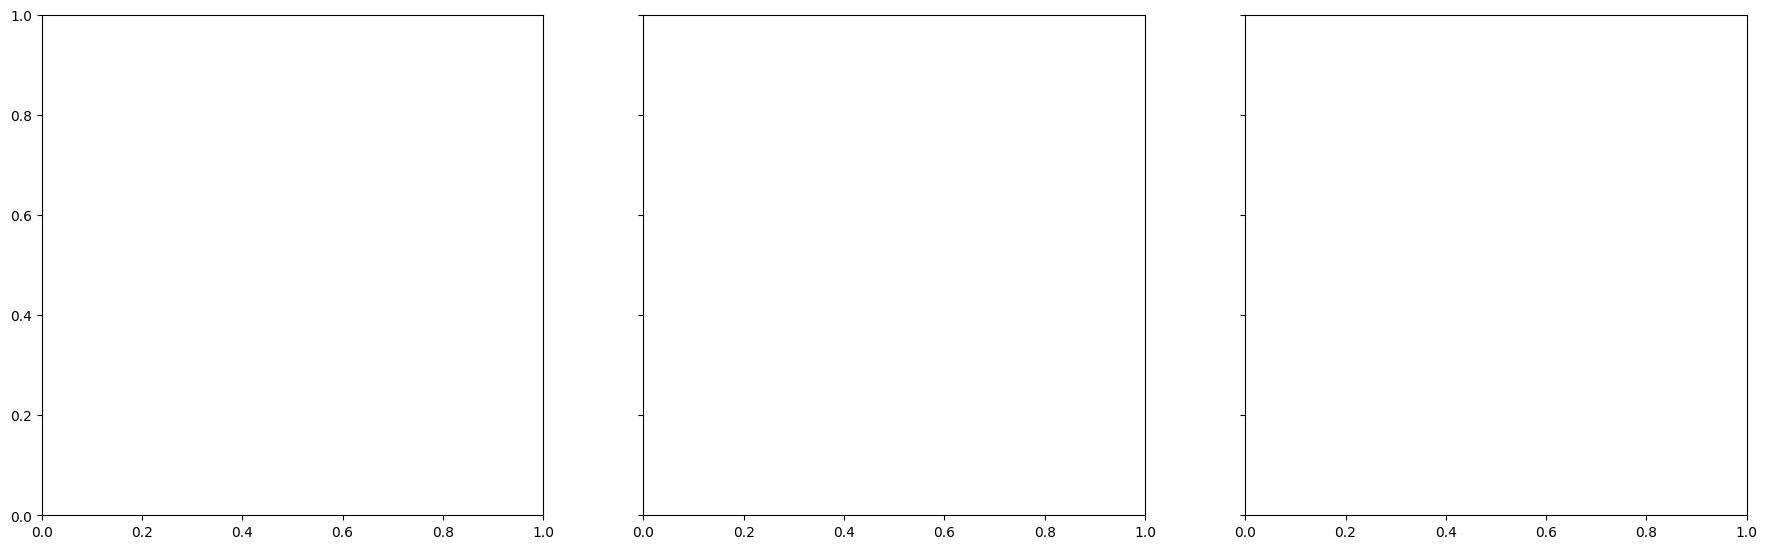

In [19]:
from sklearn.metrics import mean_squared_error, r2_score # Added r2_score

y_true_global, y_pred_global = [], []

plot_colors = {
    'desb30': '#1f77b4', 'A1': '#ff7f0e', 'detemir': '#2ca02c', 
    'A1_B29': '#d62728', 'B1_B29': '#9467bd', 'A1_B29_B1': '#8c564b', 
    'A1_B1': '#e377c2', 'B1': '#7f7f7f'
}

time_smooth = np.linspace(0, 120, 1000)
fig, axes = plt.subplots(1, 3, figsize=(22, 6.5), sharey=True)

print("=== ANALISIS ERROR PER SKENARIO RASIO ===")

# Ensure final_params exists (it was defined in your previous step)
# Then instantiate a fresh model object
model = FinalKineticModel(final_params)

for idx, r in enumerate(ratios):
    # DYNAMIC Y0: Matches your objective function logic
    desb30_t0_molL = experimental_dataset[r]['desb30'][0]
    y0 = np.zeros(len(model.species))
    y0[model.idx['nhs_myr']] = desb30_t0_molL * r
    y0[model.idx['desb30']] = desb30_t0_molL
        
    model = FinalKineticModel(final_params)
    sol_smooth = model.simulate(y0, (0, 120), time_smooth)
    sol_exp = model.simulate(y0, (0, 120), time_exp)
    
    # Use a list to store data for this ratio for local RMSE
    r_true, r_pred = [], []
    
    for sp in species_list:
        # DYNAMIC INDEXING: safer and cleaner
        ode_pos = model.idx[sp]
        
        sim_gL_smooth = sol_smooth.y[ode_pos] * MW[sp]
        sim_gL_exp = sol_exp.y[ode_pos] * MW[sp]
        exp_gL = experimental_dataset[r][sp] * MW[sp]
        
        # Masking NaNs to prevent calculation failure
        mask = ~np.isnan(exp_gL)
        r_true.extend(exp_gL[mask])
        r_pred.extend(sim_gL_exp[mask])
        
        # Add to global trackers
        y_true_global.extend(exp_gL[mask])
        y_pred_global.extend(sim_gL_exp[mask])
        
        axes[idx].plot(time_smooth, sim_gL_smooth, color=plot_colors[sp], linewidth=1.6, alpha=0.95)
        axes[idx].scatter(time_exp, exp_gL, color=plot_colors[sp], edgecolors='white', linewidth=1.1, s=65, zorder=5)

    rmse_ratio = np.sqrt(mean_squared_error(r_true, r_pred))
    print(f"Rasio 1 : {r:.1f} -> RMSE = {rmse_ratio:.4f} g/L")
    
    ax = axes[idx]
    ax.set_title(f"Rasio 1 : {r:.1f}\n(RMSE: {rmse_ratio:.3f} g/L)", fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Waktu Reaksi (Menit)", fontsize=12)
    if idx == 0:
        ax.set_ylabel("Konsentrasi Komponen (g/L)", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.4)

# Hitung Statistik Global Akhir
global_r2 = r2_score(y_true_global, y_pred_global)
global_rmse = np.sqrt(mean_squared_error(y_true_global, y_pred_global))

# Penataan Legend & Title
handles, labels = axes[0].get_legend_handles_labels()
# Mengambil label unik tiruan untuk memunculkan legenda kromatogram tanpa tulisan "(Model)" berulang
dummy_handles = [plt.Line2D([0], [0], color=plot_colors[sp], lw=2) for sp in species_list]
fig.legend(dummy_handles, species_list, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=4, fontsize=11, frameon=True)

plt.suptitle(f"Kurva Kinetika Global DE (Super Smooth)\nGlobal R² = {global_r2:.4f} ({global_r2*100:.2f}%)  |  Global RMSE = {global_rmse:.4f} g/L", 
             fontsize=14, fontweight='bold', y=1.06)

plt.tight_layout()
plt.show()

print("\n==================== RINGKASAN PERFORMA MODEL ====================")
print(f" >> Akurasi Tren (Global R²) : {global_r2:.4f} ({global_r2*100:.2f}%)")
print(f" >> Deviasi Rata-rata (Global RMSE) : {global_rmse:.4f} g/L")
print("==================================================================")

In [15]:
# Run this AFTER you define your model with final_params
# Let's see the rates at t=0 (the start of the reaction)
y0 = np.zeros(len(model.species))
y0[model.idx['desb30']] = experimental_dataset[1.0]['desb30'][0]
y0[model.idx['nhs_myr']] = y0[model.idx['desb30']] * 1.0

# Manually calculate the initial reaction rates (r1 to r7)
# This uses the same logic as your _ode_system
idx = model.idx
k = final_params[:8]
n, m = final_params[8], final_params[9]

# Use concentrations from y0
C_nhsm = y0[idx['nhs_myr']]
C_desb = y0[idx['desb30']]

r1 = k[0] * (C_nhsm**n) * (C_desb**m)
r2 = k[1] * (C_nhsm**n) * (C_desb**m)
r3 = k[2] * (C_nhsm**n) * (C_desb**m) # Detemir Pathway

print(f"Flux to A1 (r1): {r1:.4e}")
print(f"Flux to B1 (r2): {r2:.4e}")
print(f"Flux to Detemir (r3): {r3:.4e}")

Flux to A1 (r1): 3.1125e-07
Flux to B1 (r2): 4.4200e-07
Flux to Detemir (r3): 5.2308e-07


In [ ]:
# NOTE: this cell originally referenced `ExpandedKineticModel` and
# `final_params_full`, neither of which exists anywhere else in this notebook -
# it would have crashed with a NameError. Fixed to save the model that this
# notebook actually builds (`FinalKineticModel` with the fitted `final_params`).
import dill

my_final_model = FinalKineticModel(list(np.exp(res_final.x[:8])) + [res_final.x[8], res_final.x[9]])
model_file_path = 'multi_ratio_kinetic_optimized_model.dill'

with open(model_file_path, 'wb') as f:
    dill.dump(my_final_model, f)
print(f"\nKinetic MODEL Multi-Rasio sukses disimpan ke '{model_file_path}'!")


In [21]:
# Check total mass at t=0 and t=120
total_mass_t0 = np.sum([y0[model.idx[sp]] * MW[sp] for sp in model.species])
total_mass_t120 = np.sum([sol.y[model.idx[sp]][-1] * MW[sp] for sp in model.species])
print(f"Mass Balance Error: {abs(total_mass_t0 - total_mass_t120)/total_mass_t0 * 100:.2f}%")

Mass Balance Error: 216828.22%


In [10]:
# 1. Provide a realistic set of starting k-values (not from the broken optimization)
# Let's start everything at a moderate rate (e.g., 0.1)
safe_k_values = [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1] 
n, m = 1.0, 1.0 # Locked to First-Order

safe_params = safe_k_values + [n, m]
test_model = FinalKineticModel(safe_params)

# 2. Setup initial conditions for Ratio 1.0
desb30_t0_molL = experimental_dataset[1.0]['desb30'][0]
y0 = np.zeros(len(test_model.species))
y0[test_model.idx['nhs_myr']] = desb30_t0_molL * 1.0
y0[test_model.idx['desb30']] = desb30_t0_molL

# 3. Simulate with LSODA (Best for stiff chemical networks)
sol = solve_ivp(test_model._ode_system, (0, 120), y0, method='LSODA', atol=1e-9, rtol=1e-7)

if sol.success:
    mass_in = np.sum([y0[test_model.idx[sp]] * MW[sp] for sp in test_model.species])
    mass_out = np.sum([sol.y[test_model.idx[sp]][-1] * MW[sp] for sp in test_model.species])
    print(f"Sanity Check: SUCCESS!")
    print(f"Mass Balance Error: {abs(mass_in - mass_out) / mass_in * 100:.5f}%")
else:
    print("Sanity Check: FAILED. ODEs are still exploding.")

Sanity Check: SUCCESS!
Mass Balance Error: 5.39272%


INFO: File terbaca sebagai dictionary dengan keys: ['model_instance', 'parameters', 'final_sse', 'description', 'date']
INFO: Objek model ditemukan pada key: 'model_instance'

=== ANALISIS ERROR PER SKENARIO RASIO ===
Rasio 1 : 1.0 -> RMSE = 0.1786 g/L
Rasio 1 : 1.5 -> RMSE = 0.0566 g/L
Rasio 1 : 2.0 -> RMSE = 0.0585 g/L


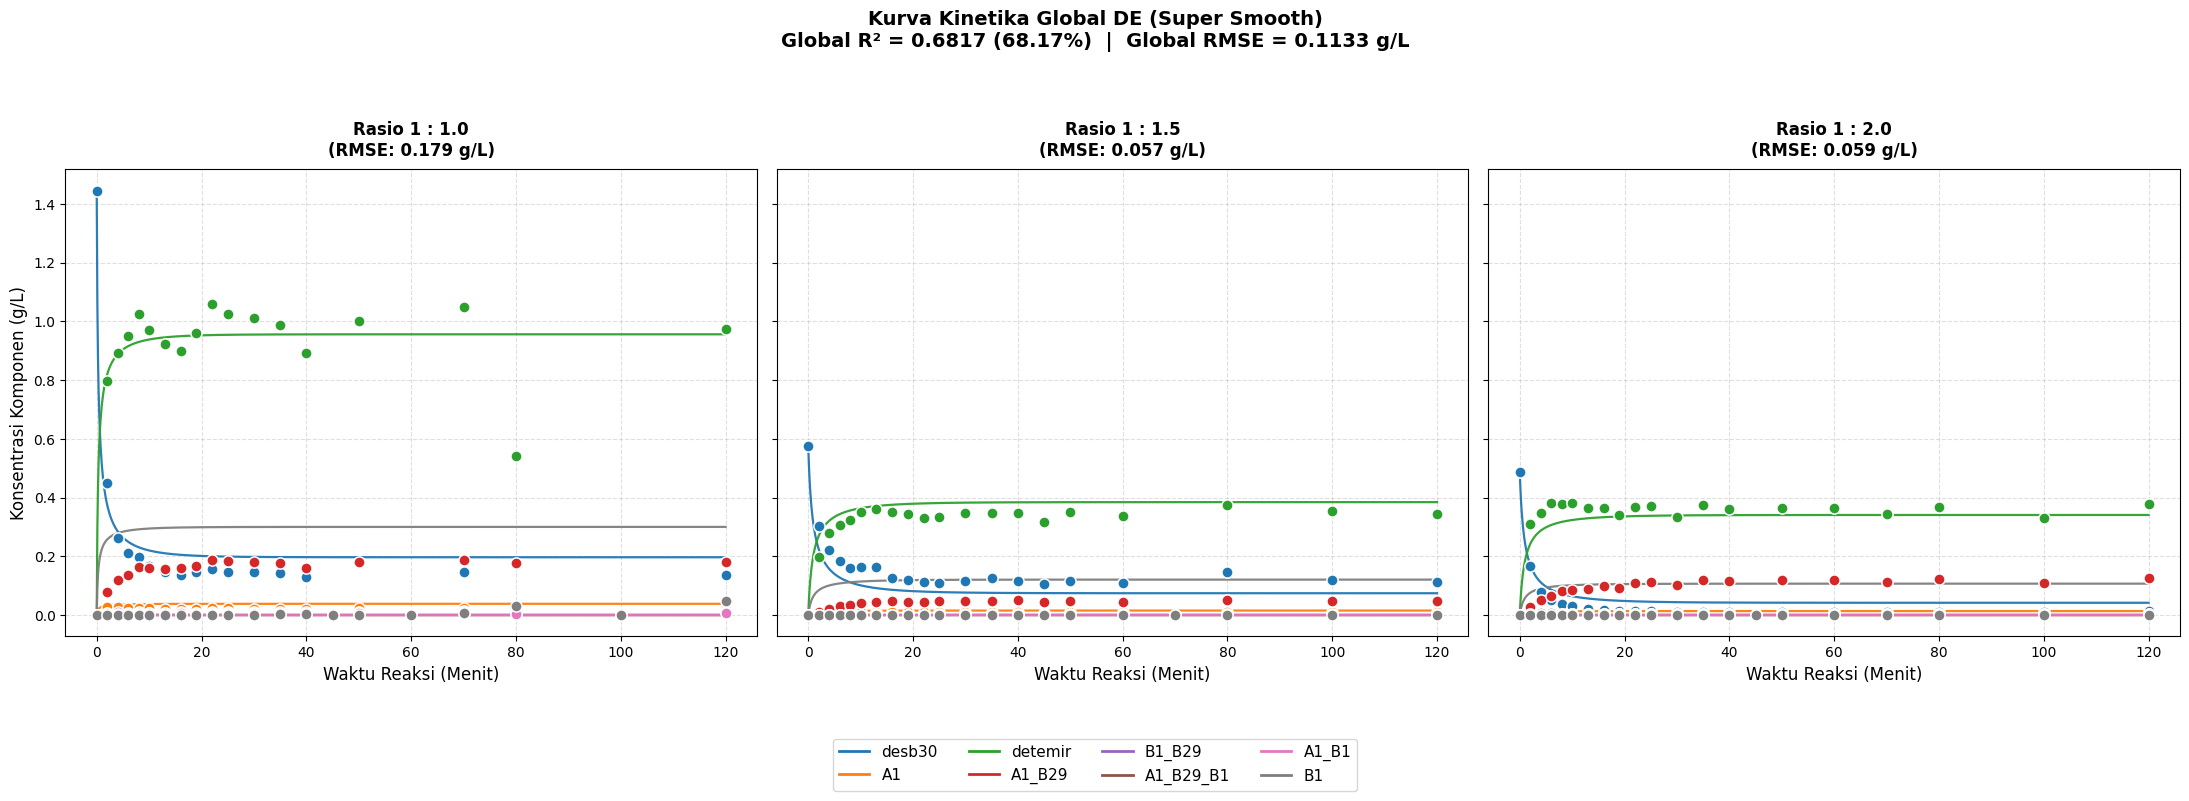


==================== RINGKASAN PERFORMA MODEL ====================
 >> Akurasi Tren (Global R²) : 0.6817 (68.17%)
 >> Deviasi Rata-rata (Global RMSE) : 0.1133 g/L


In [10]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import dill

# ==============================================================================
# 1. LOAD & UNBOXING MODEL SECARA AMAN DARI FILE .DILL
# ==============================================================================
with open('02jul2026_optimized_hydrolysis_kinetic_model.dill', 'rb') as f:
    checkpoint = dill.load(f)

# Unboxing otomatis jika model dibungkus dalam dictionary
if isinstance(checkpoint, dict):
    print("INFO: File terbaca sebagai dictionary dengan keys:", list(checkpoint.keys()))
    if 'model' in checkpoint:
        model_loaded = checkpoint['model']
    elif 'model_loaded' in checkpoint:
        model_loaded = checkpoint['model_loaded']
    else:
        # Mencari objek di dalam dict yang memiliki method 'simulate'
        model_loaded = None
        for key, val in checkpoint.items():
            if hasattr(val, 'simulate'):
                print(f"INFO: Objek model ditemukan pada key: '{key}'")
                model_loaded = val
                break
        if model_loaded is None:
            raise AttributeError("Gagal mengekstrak objek model dari dictionary. Pastikan objek model memiliki method '.simulate'.")
else:
    model_loaded = checkpoint

# ==============================================================================
# 2. PROSES VISUALISASI GRAFIK & ANALISIS ERROR
# ==============================================================================
y_true_global, y_pred_global = [], []

plot_colors = {
    'desb30': '#1f77b4', 'A1': '#ff7f0e', 'detemir': '#2ca02c', 
    'A1_B29': '#d62728', 'B1_B29': '#9467bd', 'A1_B29_B1': '#8c564b', 
    'A1_B1': '#e377c2', 'B1': '#7f7f7f'
}

time_smooth = np.linspace(0, 120, 1000)
fig, axes = plt.subplots(1, 3, figsize=(22, 6.5), sharey=True)

print("\n=== ANALISIS ERROR PER SKENARIO RASIO ===")

for idx, r in enumerate(ratios):
    # DYNAMIC Y0: Menyelaraskan dengan logika fungsi objektif Anda
    desb30_t0_molL = experimental_dataset[r]['desb30'][0]
    
    # Ambil index dan ukuran spesies secara dinamis dari model yang di-load
    y0 = np.zeros(len(model_loaded.species))
    y0[model_loaded.idx['nhs_myr']] = desb30_t0_molL * r
    y0[model_loaded.idx['desb30']] = desb30_t0_molL
        
    # Jalankan simulasi menggunakan model dari file .dill
    sol_smooth = model_loaded.simulate(y0, (0, 120), time_smooth)
    sol_exp = model_loaded.simulate(y0, (0, 120), time_exp)
    
    # Penampung lokal untuk RMSE per rasio
    r_true, r_pred = [], []
    
    for sp in species_list:
        ode_pos = model_loaded.idx[sp]
        
        sim_gL_smooth = sol_smooth.y[ode_pos] * MW[sp]
        sim_gL_exp = sol_exp.y[ode_pos] * MW[sp]
        exp_gL = experimental_dataset[r][sp] * MW[sp]
        
        # --- FIX INDEX ERROR MASKING ---
        # Mengatasi inkonsistensi jumlah titik dari solver ODE dengan interpolasi linear ke time_exp
        if len(sim_gL_exp) != len(exp_gL):
            sim_gL_exp_fixed = np.interp(time_exp, time_smooth, sim_gL_smooth)
        else:
            sim_gL_exp_fixed = sim_gL_exp
            
        # Masking NaNs pada data eksperimen (hanya menguji data riil)
        mask = ~np.isnan(exp_gL)
        valid_exp = exp_gL[mask]
        valid_sim = sim_gL_exp_fixed[mask]
        
        r_true.extend(valid_exp)
        r_pred.extend(valid_sim)
        
        # Tambahkan ke global tracker
        y_true_global.extend(valid_exp)
        y_pred_global.extend(valid_sim)
        
        # Plotting hasil simulasi kurva mulus vs data eksperimen berupa titik scatter
        axes[idx].plot(time_smooth, sim_gL_smooth, color=plot_colors[sp], linewidth=1.6, alpha=0.95)
        axes[idx].scatter(time_exp, exp_gL, color=plot_colors[sp], edgecolors='white', linewidth=1.1, s=65, zorder=5)

    rmse_ratio = np.sqrt(mean_squared_error(r_true, r_pred))
    print(f"Rasio 1 : {r:.1f} -> RMSE = {rmse_ratio:.4f} g/L")
    
    ax = axes[idx]
    ax.set_title(f"Rasio 1 : {r:.1f}\n(RMSE: {rmse_ratio:.3f} g/L)", fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Waktu Reaksi (Menit)", fontsize=12)
    if idx == 0:
        ax.set_ylabel("Konsentrasi Komponen (g/L)", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.4)

# Hitung Statistik Global Akhir
global_r2 = r2_score(y_true_global, y_pred_global)
global_rmse = np.sqrt(mean_squared_error(y_true_global, y_pred_global))

# Penataan Legend & Title
dummy_handles = [plt.Line2D([0], [0], color=plot_colors[sp], lw=2) for sp in species_list]
fig.legend(dummy_handles, species_list, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=4, fontsize=11, frameon=True)

plt.suptitle(f"Kurva Kinetika Global DE (Super Smooth)\nGlobal R² = {global_r2:.4f} ({global_r2*100:.2f}%)  |  Global RMSE = {global_rmse:.4f} g/L", 
             fontsize=14, fontweight='bold', y=1.06)

plt.tight_layout()
plt.show()

print("\n==================== RINGKASAN PERFORMA MODEL ====================")
print(f" >> Akurasi Tren (Global R²) : {global_r2:.4f} ({global_r2*100:.2f}%)")
print(f" >> Deviasi Rata-rata (Global RMSE) : {global_rmse:.4f} g/L")
print("==================================================================")